In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

:::{admonition} Download
:class: important render-all

This notebook can be downloaded as **{nb-download}`02_03_place_cells_2d_neural_tuning.ipynb`**. See the button at the top right to download as markdown or pdf.
:::

# 2D neural tuning and model fitting

<div class="render-all">
    
In this series of notebooks, we will review more advanced applications of pynapple; tuning curves, signal processing, and decoding; as well as fitting GLMs to the data using NeMoS. We'll apply these methods to demonstrate and visualize some well-known physiological properties of hippocampal activity, specifically phase presession of place cells and sequential coordination of place cell activity during theta oscillations.

This series is split into 4 notebooks:
1. Data wrangling, 1D neural tuning, and model fitting
2. Signal processing
3. (This notebook) 2D neural tuning and model fitting
4. Neural decoding

This notebook assumes you have already gone through the first notebook to explore the data. We'll reinitialize variables created in the first notebook that will be used here.

</div>

In [2]:
import workshop_utils
# imports
import math
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy as sp
import seaborn as sns
import tqdm
import pynapple as nap

# necessary for animation
import nemos as nmo
plt.style.use(nmo.styles.plot_style)

# configure pynapple to ignore conversion warning
nap.nap_config.suppress_conversion_warnings = True

# code needed from first notebook
path = workshop_utils.fetch_data("Achilles_10252013_EEG.nwb")
data = nap.load_file(path)
forward_ep = data["forward_ep"]
position = data["position"].restrict(forward_ep)
lfp = data["eeg"][:,0].restrict(forward_ep)
spikes = data["units"]
speed = np.abs(position.derivative())
good_spikes = spikes[(spikes.restrict(forward_ep).rate >= 1) & (spikes.restrict(forward_ep).rate <= 10)]
place_fields = nap.compute_tuning_curves(good_spikes, position, 50, feature_names=["position"])
speed_fields = nap.compute_tuning_curves(spikes, speed, bins=30, epochs=speed.time_support, feature_names=["speed"])
bin_size = 0.01
neurons = [82, 92, 220]
counts = good_spikes[neurons].count(bin_size, ep=forward_ep)
up_position = position.interpolate(counts)
up_speed = speed.interpolate(counts)
position_basis = nmo.basis.BSplineEval(n_basis_funcs=12, label="position")
speed_basis = nmo.basis.BSplineEval(n_basis_funcs=6, label="speed")

## Part 4: 2D neural tuning and model fitting
### Computing 2D tuning curves: position vs. phase

<div class="render-all">

We can visualize phase precession as a 2D tuning curve over position and phase. We can compute this using the same function as the first notebook, [`nap.compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves), but now passing `features` as a 2-column `TsdFrame` containing the two target features.

First we need the theta phase for our second target feature. We provide the code below for extracting theta phase from the LFP. We do this by: 1) filtering the raw signal to the theta frequency band (6-12Hz), and 2) extracting the phase from the hilbert transform. Both of these steps can be done using pynapple functions (see notebook 2 for a deeper dive into signal processing).

</div>

In [3]:
sample_rate = 1250
theta_band = nap.apply_bandpass_filter(lfp, (6.0, 12.0), fs=sample_rate)
theta_phase = nap.compute_hilbert_phase(theta_band)

<div class="render-all">

Now we need to combine `position` and `theta_phase` into a `TsdFrame`. For this to work, both variables must have the same length. We can achieve this by upsampling `position` to the length of `theta_phase` using the pynapple object method [`interpolate`](https://pynapple.org/generated/pynapple.Tsd.interpolate.html).

</div>

#### 1. Interpolate `position` to the time points of `theta_phase`.

<div class="render-user"> 
```{code-cell} ipython3
upsampled_pos = 
```
</div>

In [4]:
upsampled_pos = position.interpolate(theta_phase)

<div class="render-all">

Now we can combine `upsampled_pos` and `theta_phase` into a single `TsdFrame`. However, since comparing and merging time axes is nontrivial problem, pynapple does not allow us to do this directly. Instead, we need to extract the values from `upsampled_pos` and `theta_phase` and stack them together using `numpy`. Then we can define a new `TsdFrame` using the 2D feature array which we can use to compute 2D tuning curves.
  
</div>

#### 2. Stack `upsampled_pos` and `theta_phase` together into a single [`TsdFrame`](https://pynapple.org/generated/pynapple.TsdFrame.html)

<div class="render-all">

- For stacking arrays, you can use a numpy function like [`np.stack`](https://numpy.org/doc/stable/reference/generated/numpy.stack.html).
    - Tip: you may need to transpose to make sure time is in the first dimension of the stacked array
- Make sure to name your `TsdFrame` columns `"position"` and `"phase"`
  
</div>

<div class="render-user">  
```{code-cell} ipython3
# store the resulting TsdFrame into the following variable
features = 
```
</div>

In [5]:
feats = np.stack((upsampled_pos.values, theta_phase.values))
features = nap.TsdFrame(
    t=theta_phase.t,
    d=np.transpose(feats),
    time_support=upsampled_pos.time_support,
    columns=["position", "phase"],
)
features

Time (s)      position    phase
----------  ----------  -------
18193.5992     6.31836  5.38742
18193.6        6.33044  5.74591
18193.6008     6.34251  5.76537
18193.6016     6.35459  5.9562
18193.6024     6.36667  5.9812
18193.6032     6.37875  6.12091
18193.604      6.39082  6.14975
...
20123.392    165.232    4.72464
20123.3928   165.24     4.71239
20123.3936   165.248    4.71239
20123.3944   165.256    4.71239
20123.3952   165.264    4.71239
20123.396    165.272    4.71239
20123.3968   165.28     4.71239
dtype: float64, shape: (240384, 2)

#### 3. Use [`nap.compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves) to compute 2D tuning curves for our subselected group of units, `good_spikes`, over position and phase stored in `features`.

<div class="render-all">

- Use 50 bins for position and 30 bins for theta phase

</div>

<div class="render-user">
```{code-cell} ipython3
tuning_curves =
```
</div>

In [6]:
tuning_curves = nap.compute_tuning_curves(good_spikes, features, bins=[50,30])

<div class="render-all">

We can plot 2D tuning curves for each unit and phase precession in some example units.

</div>

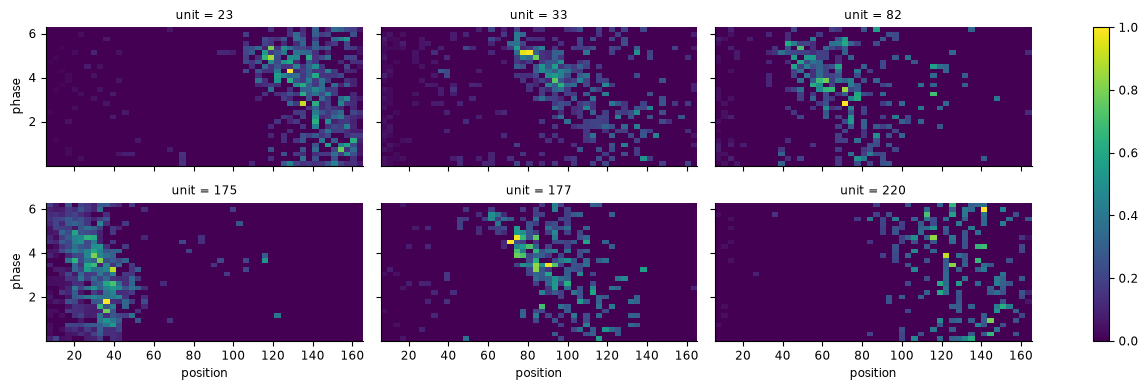

In [7]:
neurons = [23, 33, 82, 175, 177, 220]
tc_norm = tuning_curves / tuning_curves.max(axis=(1,2))
p = tc_norm.sel(unit=neurons).plot(x="position", y="phase", col="unit", col_wrap=3, size=2, aspect=2)

In [8]:
p.fig.savefig("../../../_static/_check_figs/pc-12.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/pc-12.png)
:::
</div>

<div class="render-all">

You should be able to notice a negative relationship between position and phase, characteristic of phase precession.

</div>

### Estimating 2D tuning curves using 2D basis functions

<div class="render-all">
    
How can we model 2D tuning curves in a GLM? Similar the first notebook, we can define a 2D basis by using [NeMoS basis composition](https://nemos.readthedocs.io/en/latest/background/basis/plot_02_ND_basis_function.html), but instead *multiplying* two basis objects. In fact, we can use both addition and multiplication together to create arbitrarily complex, multidimensional basis objects.

First, we'll create a basis object for theta phase, specifically using [`CyclicBSplineEval`](https://nemos.readthedocs.io/en/latest/generated/basis/nemos.basis.CyclicBSplineEval.html#nemos.basis.BSplineEval). We use this instead of `BSplineBasis` because the phase angle is a circular variable.

</div>

#### 4. Instantiate a [`CyclicBSplineEval`](https://nemos.readthedocs.io/en/latest/generated/basis/nemos.basis.CyclicBSplineEval.html#nemos.basis.BSplineEval) basis object for phase, using 10 basis functions.

<div class="render-all">

- Provide the label `"phase"` for the basis.
- If necessary, reinstantiate the basis objects for position, `position_basis`, and speed, `speed_basis`, as you did in **2.6**.

</div>

<div class="render-user">
```{code-cell} ipython3
phase_basis =
```
</div>

In [9]:
phase_basis = nmo.basis.CyclicBSplineEval(n_basis_funcs=10, label="phase")

#### 5. Create the full basis by multiplying `position_basis` and `phase_basis` and adding `speed_basis`.

<div class="render-user">
```{code-cell} ipython3
full_basis =
```
</div>

In [10]:
full_basis = position_basis * phase_basis + speed_basis
full_basis

,label,'((position * phase) + speed)'
,position__bounds,None
,position__fill_value,nan
,position__label,'position'
,position__n_basis_funcs,12
,position__order,4
,position,"'position': B...s=12, order=4)"
,phase__bounds,None
,phase__fill_value,nan
,phase__label,'phase'
,phase__n_basis_funcs,10


<div class="render-all">

Before we can call `compute_features`, we need to make sure `theta_phase` has the same number of time points as `counts`. Since `theta_phase` has *more* time points than counts, we'll need to *downsample* the number of time points. We can do this using the pynapple object method [`bin_average`](https://pynapple.org/generated/pynapple.Tsd.bin_average.html). This function will average values within a specified bin size. We can achieve the same sampling rate by using the same bin size as we used for our spike counts.

</div>

#### 6. Downsample `theta_phase` using `bin_average` and a bin size of 0.01 s.

<div class="render-user">
```{code-cell} ipython3
bin_theta =
```
</div>

In [11]:
bin_theta = theta_phase.bin_average(0.01)

#### 7. Create a design matrix by calling `compute_features` on `full_basis` using `up_position`, `bin_theta`, and `up_speed`
<div class="render-all">

- Note: `up_position` and `up_speed` were computed in the first notebook and have been redefined above.

</div>

<div class="render-user">
```{code-cell} ipython3
X =
```
</div>

In [12]:
X = full_basis.compute_features(up_position, bin_theta, up_speed)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


<div class="render-all">

Now we have everything we need to fit a GLM and predict the 2D tuning curves from our model.
  
</div>

#### 8. Fit a GLM by doing the following:

<div class="render-all">

- Initialize `PopulationGLM`
- Use the "LBFGS" solver and pass `{"tol": 1e-12}` to `solver_kwargs`.
- Fit the data, passing the design matrix `X` and spike counts `counts` to the glm object.
    - Note: `counts` was computed in the first notebook and has been redefined above.
  
</div>


<div class="render-user">
```{code-cell} ipython3
glm =
```
</div>

In [13]:
glm = nmo.glm.PopulationGLM(
    solver_kwargs=dict(tol=10**-12),
    solver_name="LBFGS"
)

glm.fit(X, counts)

/home/jenkins/agent/workspace/rse_ccn-software-fens-2026_PR-10/.venv/lib/python3.12/site-packages/nemos/glm/glm.py:841: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f9a600565c0>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{'tol': 1e-12}
,regularizer_strength,None
,feature_mask,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float32](126, 3)",Array([[ 1.66...dtype=float32)
dof_resid_,"ArrayImpl[float32](3,)",Array([19111....dtype=float32)


#### 9. Use [`predict`](https://nemos.readthedocs.io/en/latest/generated/glm/nemos.glm.GLM.predict.html#nemos.glm.GLM.predict) to calculated the predicted firing rate of our model. Use the predicted rate to compute predicted tuning curves using [`nap.compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves).

<div class="render-all">

- Remember to convert the predicted firing rate to spikes per second!
- Compute 1D tuning curves for position, using 50 and naming the feature `"position"`.
- Compute 1D tuning curves for speed, using 30 bins and naming the feature `"speed"`.
- Compute 2D tuning curves for position x phase using `predicted_rate` and the TsdFrame `features`, using 50 bins for position and 30 bins for phase.

</div>

<div class="render-user">
```{code-cell} ipython3
# predict the model's firing rate
predicted_rate =
# compute the 1D tuning curves for position and speed
glm_pf = 
glm_speed = 
# compute 2D tuning curves for position x phase
glm_pos_theta =   
```
</div>

In [14]:
predicted_rate = glm.predict(X) / bin_size

glm_pf = nap.compute_tuning_curves(predicted_rate, position, 50, feature_names=["position"])
glm_speed = nap.compute_tuning_curves(predicted_rate, speed, 30, feature_names=["speed"])
glm_pos_theta = nap.compute_tuning_curves(
    predicted_rate, features, [50, 30], epochs=forward_ep
)

<div class="render-all">

We'll use a helper function from NeMoS to compare the predicted tuning curves to those computed from the data

</div>

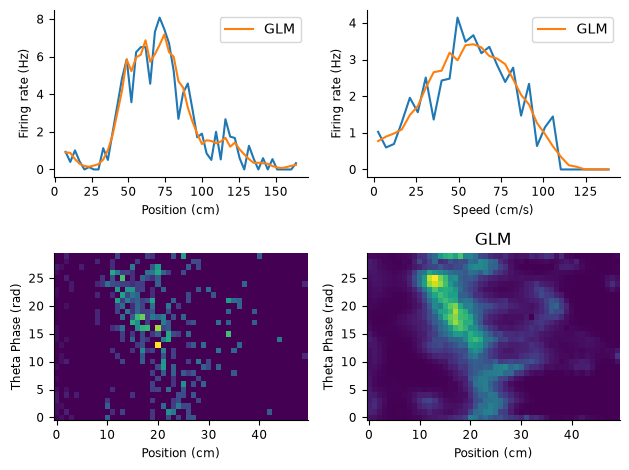

In [15]:
from nemos import _documentation_utils as doc_plots
neuron = 82
idx = np.where(glm_pf.unit == neuron)[0][0]
fig = doc_plots.plot_position_phase_speed_tuning(
    place_fields.sel(unit=neuron),
    glm_pf[idx],
    speed_fields.sel(unit=neuron),
    glm_speed[idx],
    tuning_curves.sel(unit=neuron),
    glm_pos_theta[idx],
    )

In [16]:
fig.savefig("../../../_static/_check_figs/pc-13.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/pc-13.png)
:::
</div>


### Bonus Exercise

<div class="render-all">

As an bonus, more open-ended exercise, we can investigate all the scientific decisions that we swept under the rug: should we regularize the model? What basis should we use? Do we need all inputs? If you're feeling ambitious, here are some suggestions to answer these questions:

- Try to fit and compare the results we just obtained with different models: 
  - A model with position as the only predictor.
  - A model with speed as the only predictor.
  - A model with phase as the only predictor
- Introduce L1 (Lasso) regularization and fit models with increasingly large penalty strengths ($\lambda$). Plot the regularization path showing how each coefficient changes with $\lambda$. Identify which coefficients remain non-zero longest as $\lambda$ increases - these correspond to the most informative predictors.

</div>

In [17]:
# bonus exercise